Based on https://www.datacamp.com/tutorial/sam2-fine-tuning

**Getting the data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [ ]:
import glob
train_data = []
for fn in glob.glob('/content/drive/MyDrive/MicCleaner/*/mics/*.npy', recursive=True):
   train_data.append({
       "image": fn,
       "annotation": fn.replace('/mics/', '/masks_proc/')
   })

In [ ]:
def random_k90_flip(img, mask, points=None, rng=None):
    """
    Apply the same random rotation by {0,90,180,270} and optional flip ('h' or 'v')
    to image, mask, and (optionally) points. No interpolation is used.
    """
    rng = np.random.default_rng() if rng is None else rng
    H, W = img.shape[:2]

    k = rng.integers(0, 4)             # rotation in quarter-turns CCW
    flip_axis = rng.choice(['none', 'h', 'v'])  # choose one axis or none

    # rotate
    img2  = np.rot90(img, k, axes=(0, 1))
    mask2 = np.rot90(mask, k)

    # flip
    if flip_axis != 'none':
        img2  = np.flip(img2, 1 if flip_axis=='h' else 0)
        mask2  = np.flip(mask2, 1 if flip_axis=='h' else 0)

    return img2, mask2


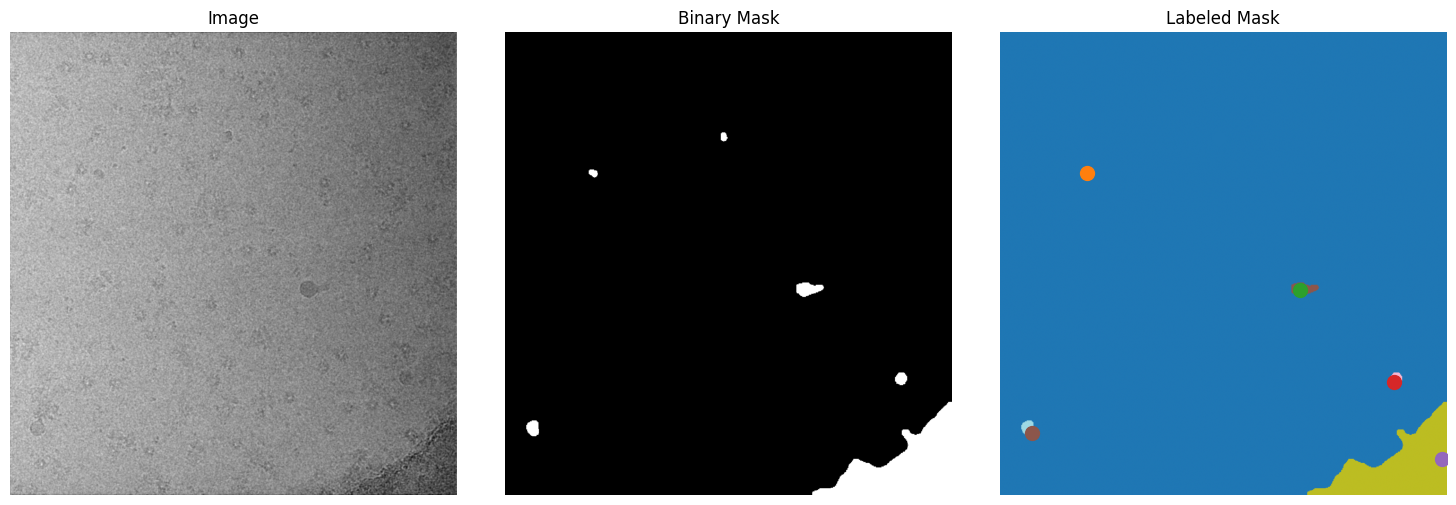

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2
def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    img = np.load(ent["image"])                         # (H,W) grayscale
    binary_mask = np.load(ent["annotation"]).astype(np.uint8)  # (H,W) 0/1
    img, binary_mask = random_k90_flip(img, binary_mask)

    # Grayscale -> RGB uint8
    img_rgb = (255 * (img - img.min()) / (img.max() - img.min())).astype(np.uint8)
    img_rgb = np.stack([img_rgb] * 3, axis=-1)          # (H,W,3)

    # Resize image and mask (keep them consistent)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    new_w, new_h = int(img.shape[1] * r), int(img.shape[0] * r)
    img = cv2.resize(img_rgb, (new_w, new_h))           # <- use RGB version
    binary_mask = cv2.resize(binary_mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    binary_mask = (binary_mask > 0).astype(np.uint8)    # ensure {0,1}

    # Connected components on resized mask
    num_labels, labeled_mask = cv2.connectedComponents(binary_mask)

    # Erode to avoid boundary points
    eroded_mask = cv2.erode(binary_mask, np.ones((5, 5), np.uint8), iterations=1)

    # Get one prompt point per surviving component + build instance masks aligned with points
    points = []
    masks_list = []
    inds = np.unique(labeled_mask)[1:]  # Skip background (0)
    for lab in inds:
        coords_i = np.argwhere((labeled_mask == lab) & (eroded_mask > 0))
        if coords_i.size == 0:
            continue  # skip if erosion removed it entirely
        yx = coords_i[np.random.randint(len(coords_i))]
        points.append([int(yx[1]), int(yx[0])])  # [x, y]
        masks_list.append((labeled_mask == lab).astype(np.uint8))  # (H,W) for this instance

    if len(points) == 0:
        # No prompts this sample
        points = np.empty((0, 1, 2), dtype=np.float32)
        binary_mask = np.empty((0, binary_mask.shape[0], binary_mask.shape[1]), dtype=np.uint8)
        num_masks = 0
    else:
        points = np.array(points, dtype=np.float32)          # (N,2)
        points = np.expand_dims(points, axis=1)              # (N,1,2) for SAM
        binary_mask = np.stack(masks_list, axis=0)           # (N,H,W)
        num_masks = len(points)

    if visualize_data:
        plt.figure(figsize=(15, 5))
        # Original (resized) Image
        plt.subplot(1, 3, 1); plt.title('Image'); plt.imshow(img); plt.axis('off')
        # Combined Binary Mask
        plt.subplot(1, 3, 2); plt.title('Binary Mask'); plt.imshow((binary_mask.sum(0) > 0), cmap='gray'); plt.axis('off')
        # Labeled Mask
        plt.subplot(1, 3, 3); plt.title('Labeled Mask'); plt.imshow(labeled_mask, cmap='tab20'); plt.axis('off')
        # Overlay points
        for p in points.reshape(-1, 2):
            plt.scatter(p[0], p[1], s=100)
        plt.tight_layout(); plt.show()

    # Return the resized RGB image, per-instance masks (N,H,W), points (N,1,2), and count
    return img, binary_mask, points, num_masks

img, binary_mask, points, num_masks = read_batch(train_data, visualize_data=True)

**Getting the SAM model**

https://github.com/facebookresearch/sam2

In [ ]:
!pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip install -U sam2

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 5.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.1 MB/s eta 0:00:00
  Created wheel for sam2: filename=sam2-1.1.0-cp312-cp312-linux_x86_64.whl size=473772 sha256=f2f0492737b324c0ceea2df0b91932d7b3508c19d3a01f051713bd21e97273dd
  Stored in directory: /root/.cache/pip/wheels/22/cb/54/0351e695a7a2e8eed8d5987cd02d8e5227eec87b0bbcc00094
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=23806bc241918f29d6b351c39df95dde4843f4c8734dbba49851b881a92e5f0b
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c

In [ ]:
#!wget https://raw.githubusercontent.com/facebookresearch/sam2/main/sam2/configs/sam2.1/sam2.1_hiera_t.yaml
!wget https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt

--2025-09-10 15:05:42--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 99.84.41.80, 99.84.41.129, 99.84.41.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|99.84.41.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 156008466 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘sam2.1_hiera_tiny.pt’

sam2.1_hiera_tiny.p 100%[===================>] 148.78M   300MB/s    in 0.5s    

2025-09-10 15:05:43 (300 MB/s) - ‘sam2.1_hiera_tiny.pt’ saved [156008466/156008466]



In [ ]:
from importlib.resources import files
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor
import torch
import torch.nn.utils

sam2_checkpoint = "/content/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

sam2_model = build_sam2(model_cfg, sam2_checkpoint, device="cuda" if torch.cuda.is_available() else "cpu")
predictor = SAM2ImagePredictor(sam2_model)
predictor.model.load_state_dict(torch.load("fine_tuned_sam2_3000.torch"))


<All keys matched successfully>

**Fine tuning**

In [ ]:
# Train mask decoder.
predictor.model.sam_mask_decoder.train(True)

# Train prompt encoder.
predictor.model.sam_prompt_encoder.train(True)

# Configure optimizer.
optimizer=torch.optim.AdamW(params=predictor.model.parameters(),lr=0.0001,weight_decay=1e-4) #1e-5, weight_decay = 4e-5

# Mix precision.
scaler = torch.amp.GradScaler()

# No. of steps to train the model.
NO_OF_STEPS = 3000 # @param

# Fine-tuned model name.
FINE_TUNED_MODEL_NAME = "fine_tuned_sam2"

In [ ]:
# Initialize scheduler
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.2) # 500 , 250, gamma = 0.1
accumulation_steps = 4  # Number of steps to accumulate gradients before updating

amp_device = 'cuda' if torch.cuda.is_available() else 'cpu'
mean_iou = 0
for step in range(1, NO_OF_STEPS + 1):
   with torch.amp.autocast(amp_device):
       image, mask, input_point, num_masks = read_batch(train_data, visualize_data=False)
       if image is None or mask is None or num_masks == 0:
           continue

       input_label = np.ones((num_masks, 1))
       if not isinstance(input_point, np.ndarray) or not isinstance(input_label, np.ndarray):
           continue

       if input_point.size == 0 or input_label.size == 0:
           continue

       predictor.set_image(image)
       mask_input, unnorm_coords, labels, unnorm_box = predictor._prep_prompts(input_point, input_label, box=None, mask_logits=None, normalize_coords=True)
       if unnorm_coords is None or labels is None or unnorm_coords.shape[0] == 0 or labels.shape[0] == 0:
           continue

       sparse_embeddings, dense_embeddings = predictor.model.sam_prompt_encoder(
           points=(unnorm_coords, labels), boxes=None, masks=None,
       )

       batched_mode = unnorm_coords.shape[0] > 1
       high_res_features = [feat_level[-1].unsqueeze(0) for feat_level in predictor._features["high_res_feats"]]
       low_res_masks, prd_scores, _, _ = predictor.model.sam_mask_decoder(
           image_embeddings=predictor._features["image_embed"][-1].unsqueeze(0),
           image_pe=predictor.model.sam_prompt_encoder.get_dense_pe(),
           sparse_prompt_embeddings=sparse_embeddings,
           dense_prompt_embeddings=dense_embeddings,
           multimask_output=True,
           repeat_image=batched_mode,
           high_res_features=high_res_features,
       )
       prd_masks = predictor._transforms.postprocess_masks(low_res_masks, predictor._orig_hw[-1])

       gt_mask = torch.tensor(mask.astype(np.float32)).cuda()
       prd_mask = torch.sigmoid(prd_masks[:, 0])
       seg_loss = (-gt_mask * torch.log(prd_mask + 0.000001) - (1 - gt_mask) * torch.log((1 - prd_mask) + 0.00001)).mean()

       inter = (gt_mask * (prd_mask > 0.5)).sum(1).sum(1)
       iou = inter / (gt_mask.sum(1).sum(1) + (prd_mask > 0.5).sum(1).sum(1) - inter)
       score_loss = torch.abs(prd_scores[:, 0] - iou).mean()
       loss = seg_loss + score_loss * 0.05

       # Apply gradient accumulation
       loss = loss / accumulation_steps
       scaler.scale(loss).backward()

       # Clip gradients
       torch.nn.utils.clip_grad_norm_(predictor.model.parameters(), max_norm=1.0)

       if step % accumulation_steps == 0:
           scaler.step(optimizer)
           scaler.update()
           predictor.model.zero_grad()

       # Update scheduler
       scheduler.step()

       if step % 500 == 0:
           FINE_TUNED_MODEL = FINE_TUNED_MODEL_NAME + "_" + str(step) + ".torch"
           torch.save(predictor.model.state_dict(), FINE_TUNED_MODEL)

       mean_iou = mean_iou * 0.99 + 0.01 * np.mean(iou.cpu().detach().numpy())

       if step%1 == 0:
           print("Step " + str(step) + ":\t", "Accuracy (IoU) = ", mean_iou)

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Step 1:	 Accuracy (IoU) =  0.007451067
Step 2:	 Accuracy (IoU) =  0.016565256
Step 3:	 Accuracy (IoU) =  0.022711212
Step 5:	 Accuracy (IoU) =  0.029186107
Step 6:	 Accuracy (IoU) =  0.03648521
Step 7:	 Accuracy (IoU) =  0.04262775
Step 8:	 Accuracy (IoU) =  0.049114842
Step 9:	 Accuracy (IoU) =  0.055627413
Step 10:	 Accuracy (IoU) =  0.057680324
Step 11:	 Accuracy (IoU) =  0.0598107
Step 12:	 Accuracy (IoU) =  0.066465825
Step 13:	 Accuracy (IoU) =  0.0711725
Step 14:	 Accuracy (IoU) =  0.076746486
Step 15:	 Accuracy (IoU) =  0.081684224
Step 17:	 Accuracy (IoU) =  0.08429468
Step 18:	 Accuracy (IoU) =  0.0893158
Step 19:	 Accuracy (IoU) =  0.09526952
Step 20:	 Accuracy (IoU) =  0.101563975
Step 21:	 Accuracy (IoU) =  0.10513085
Step 22:	 Accuracy (IoU) =  0.11122658
Step 23:	 Accuracy (IoU) =  0.116824575
Step 24:	 Accuracy (IoU) =  0.12201419
Step 25:	 Accuracy (IoU) =  0.12639084
Step 26:	 Accuracy (IoU) =  0.13234109
Step 27:	 Accuracy (IoU) =  0.1387117
Step 28:	 Accuracy (IoU) 

In [ ]:
image, true_mask, input_point, num_masks = read_batch(train_data, visualize_data=False)
H, W = image.shape[:2]
predictor.set_image(image)
masks, scores, _ = predictor.predict(
    point_coords=None,
    point_labels=None,
    box=np.array([0, 0, W-1, H-1], dtype=np.float32)[None, :],
    multimask_output=True
)
#k = scores[0].argmax()
#predicted_mask = (masks[0, k] > 0).astype(np.uint8)

(np.float64(-0.5), np.float64(1022.5), np.float64(988.5), np.float64(-0.5))

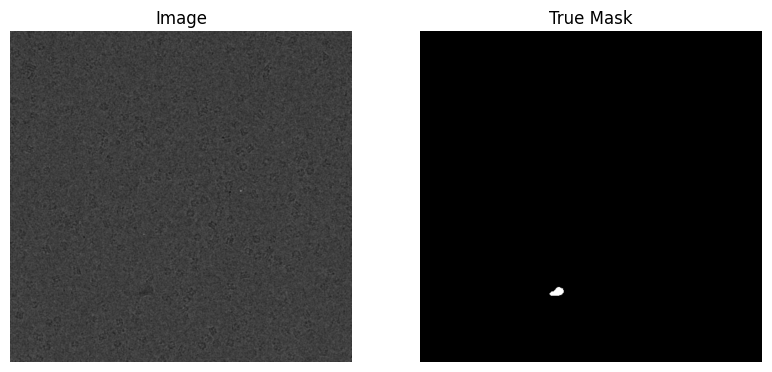

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1); plt.title('Image'); plt.imshow(image); plt.axis('off')
plt.subplot(1, 3, 2); plt.title('True Mask'); plt.imshow((true_mask.sum(0) > 0), cmap='gray'); plt.axis('off')

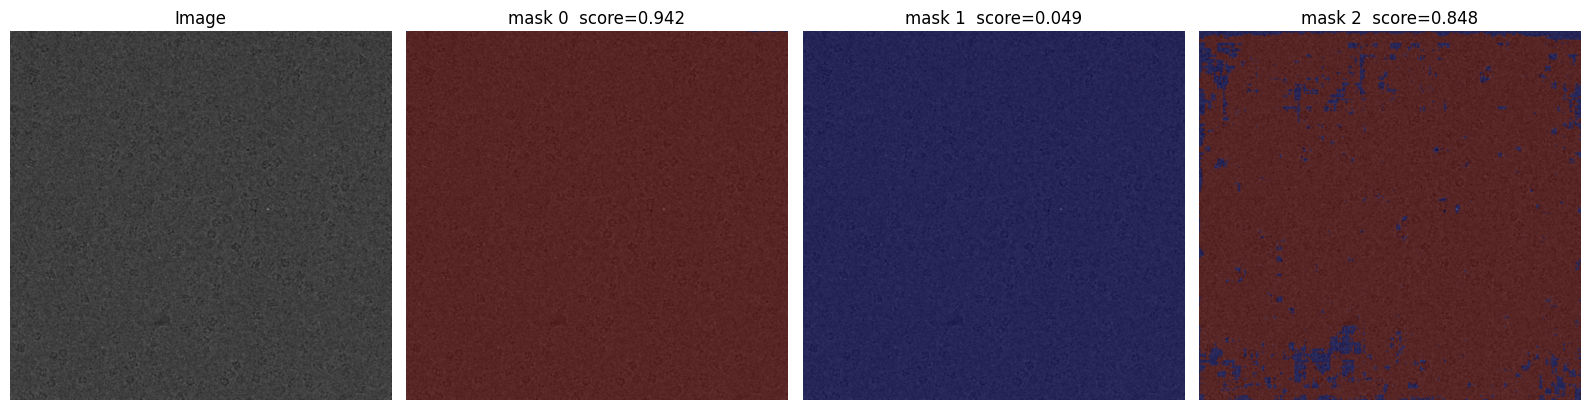

In [ ]:
# Ensure numpy
masks_np  = np.asarray(masks)              # (3, H, W)
scores_np = np.asarray(scores).squeeze()   # (3,)

K, H, W = masks_np.shape

# Show each proposal overlaid on the image
fig, axes = plt.subplots(1, K+1, figsize=(4*(K+1), 4))
axes[0].imshow(image)                      # image is (H,W,3)
axes[0].set_title('Image'); axes[0].axis('off')

for i in range(K):
    axes[i+1].imshow(image)
    axes[i+1].imshow(masks_np[i] > 0, cmap='jet', alpha=0.4)  # or >0.5 if float
    title = f"mask {i}  score={scores_np[i]:.3f}" if scores_np.ndim==1 and scores_np.size==K else f"mask {i}"
    axes[i+1].set_title(title)
    axes[i+1].axis('off')

plt.tight_layout(); plt.show()